# fio DFS Heatmap Sweep — 256 Queue Depth

Analyzes `rand_write` results from a sweep of `(numjobs, iodepth)` pairs
where `numjobs × iodepth = 256` (constant total queue depth), block size = 1 MiB.

In [1]:
import json
import glob
import re
from pathlib import Path

import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker

RESULTS_DIR = Path(".")

In [2]:
def parse_file(fpath):
    m = re.search(r"fio_bs(\S+?)_nj(\d+)_iod(\d+)_", Path(fpath).name)
    bs, nj, iod = m.group(1), int(m.group(2)), int(m.group(3))

    with open(fpath) as f:
        d = json.load(f)

    job   = d["jobs"][0]
    w     = job["write"]
    slat  = w["slat_ns"]
    clat  = w["clat_ns"]
    lat   = w["lat_ns"]
    cp    = clat["percentile"]

    def ms(v): return v / 1e6

    return dict(
        numjobs       = nj,
        iodepth       = iod,
        block_size    = bs,
        bw_GiBs       = w["bw"] / 1024 / 1024,
        iops          = w["iops"],
        # submission latency
        slat_min_ms   = ms(slat["min"]),
        slat_mean_ms  = ms(slat["mean"]),
        slat_max_ms   = ms(slat["max"]),    
        # completion latency
        clat_50th_ms  = ms(cp["50.000000"]),
        clat_90th_ms  = ms(cp["90.000000"]),
        clat_99th_ms  = ms(cp["99.000000"]),
        clat_99_9th_ms = ms(cp["99.900000"]),
        # total latency
        lat_min_ms    = ms(lat["min"]),
        lat_mean_ms   = ms(lat["mean"]),
        lat_max_ms    = ms(lat["max"]),             
    )

files = sorted(RESULTS_DIR.glob("*.json"))
df = pd.DataFrame([parse_file(f) for f in files]).sort_values("numjobs").reset_index(drop=True)
df["label"] = df.apply(lambda r: f"nj={r.numjobs}\niod={r.iodepth}", axis=1)
print(f"Loaded {len(df)} result files")

df


Loaded 5 result files


,numjobs,iodepth,block_size,bw_GiBs,iops,slat_min_ms,slat_mean_ms,slat_max_ms,clat_50th_ms,clat_90th_ms,clat_99th_ms,clat_99_9th_ms,lat_min_ms,lat_mean_ms,lat_max_ms,label
0,4,64,1M,21.543531,22060.576779,0.023681,0.034956,5.908618,5.603328,18.743296,103.284736,133.693440,0.895370,11.521331,164.952732,nj=4\niod=64
1,8,32,1M,22.105309,22635.836610,0.024941,0.035581,9.325400,8.224768,17.956864,42.729472,68.681728,0.515119,11.226907,161.499401,nj=8\niod=32
2,16,16,1M,22.969672,23520.945113,0.024780,0.036782,16.630482,9.371648,16.580608,26.345472,39.583744,0.308106,10.800903,95.818454,nj=16\niod=16
3,32,8,1M,22.706928,23251.895296,0.026691,0.041656,48.582688,10.158080,11.730944,20.578304,30.801920,0.328327,10.923915,83.059317,nj=32\niod=8
4,64,4,1M,22.931343,23481.695633,0.026781,0.052837,59.077628,10.420224,10.944512,20.054016,30.277632,0.299047,10.815804,131.999720,nj=64\niod=4


## Bandwidth & IOPS

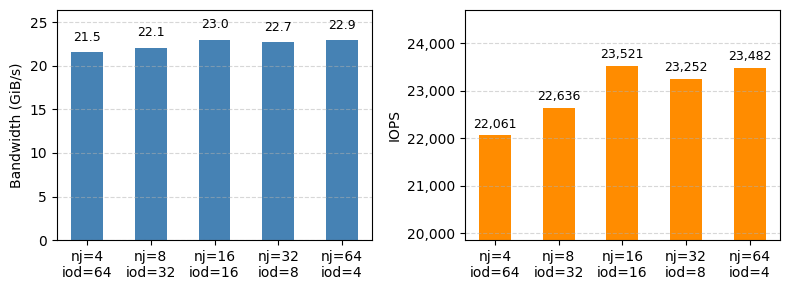

In [3]:
fig, axes = plt.subplots(1, 2, figsize=(8, 3))

axes[0].bar(df["label"], df["bw_GiBs"], color="steelblue", width=0.5)
axes[0].set_ylabel("Bandwidth (GiB/s)")
axes[0].yaxis.set_major_formatter(ticker.FuncFormatter(lambda x, _: f"{x:,.0f}"))
axes[0].set_ylim(0, df["bw_GiBs"].max() * 1.15)
for bar, v in zip(axes[0].patches, df["bw_GiBs"]):
    axes[0].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 1,
                 f"{v:,.1f}", ha="center", va="bottom", fontsize=9)

axes[1].bar(df["label"], df["iops"], color="darkorange", width=0.5)
axes[1].set_ylabel("IOPS")
axes[1].yaxis.set_major_formatter(ticker.FuncFormatter(lambda x, _: f"{x:,.0f}"))
axes[1].set_ylim(df["iops"].min() * 0.9, df["iops"].max() * 1.05)
for bar, v in zip(axes[1].patches, df["iops"]):
    axes[1].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 100,
                 f"{v:,.0f}", ha="center", va="bottom", fontsize=9)

for ax in axes:
    # ax.set_xlabel("numjobs / iodepth")
    ax.grid(axis="y", linestyle="--", alpha=0.5)

plt.tight_layout()
plt.savefig(RESULTS_DIR / "bw_iops.pdf", dpi=150)
plt.show()

## Latency Breakdown Plot

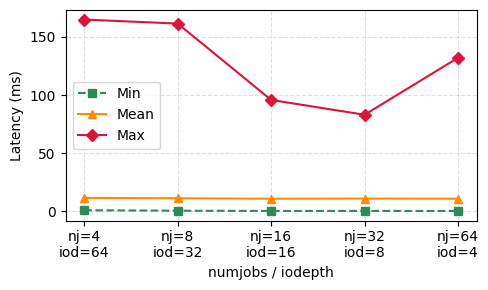

In [4]:
fig, ax = plt.subplots(figsize=(5, 3))

x = range(len(df))
ax.plot(x, df["lat_min_ms"],   "s--", label="Min",    color="seagreen")
ax.plot(x, df["lat_mean_ms"],   "^-",  label="Mean",    color="darkorange")
ax.plot(x, df["lat_max_ms"],  "D-",  label="Max",  color="crimson")

ax.set_xticks(list(x))
ax.set_xticklabels(df["label"])
ax.set_xlabel("numjobs / iodepth")
ax.set_ylabel("Latency (ms)")
ax.legend(loc="best")
ax.grid(linestyle="--", alpha=0.4)

plt.tight_layout()
plt.savefig(RESULTS_DIR / "latency.pdf", dpi=150)
plt.show()

## Tail Latency Detail (p99 / p99.9)

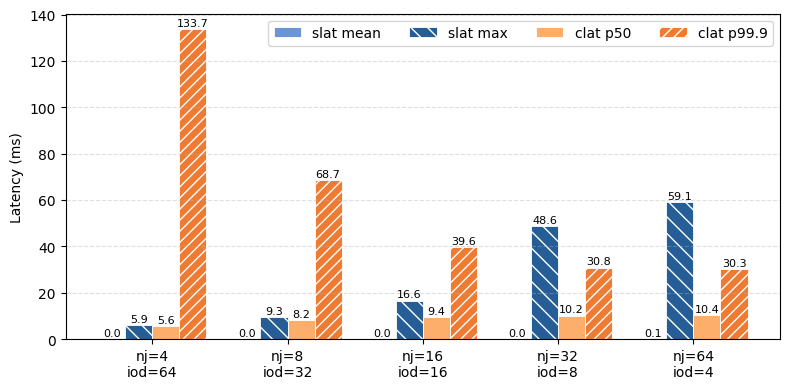

In [6]:
# ColorBrewer sequential tones — print-safe and colorblind-friendly
COLORS  = ["#6B96D6", "#255D96", "#FDAE6B", "#EF7B33"]
HATCHES = ["",        "\\\\",     "",        "///"]

metrics = [
    ("slat_mean_ms",   "slat mean"),
    ("slat_max_ms",    "slat max"),
    ("clat_50th_ms",   "clat p50"),
    ("clat_99_9th_ms", "clat p99.9"),
]
n  = len(metrics)
w  = 0.8 / n
x  = list(range(len(df)))
offsets = [(i - (n - 1) / 2) * w for i in range(n)]

fig, ax = plt.subplots(figsize=(8, 4))

for (col, label), offset, color, hatch in zip(metrics, offsets, COLORS, HATCHES):
    bars = ax.bar([xi + offset for xi in x], df[col], w,
                  label=label, color=color, hatch=hatch,
                  edgecolor="white", linewidth=0.6)
    for bar in bars:
        ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.5,
                f"{bar.get_height():.1f}", ha="center", va="bottom",
                fontsize=8, rotation=0)

ax.set_xticks(x)
ax.set_xticklabels(df["label"])
# ax.set_xlabel("numjobs / iodepth")
ax.set_ylabel("Latency (ms)")
ax.legend(ncol=n, loc="upper right", fontsize=10)
ax.grid(axis="y", linestyle="--", alpha=0.4)

plt.tight_layout()
plt.savefig(RESULTS_DIR / "tail_latency_breakdown.pdf", dpi=150)
plt.show()
